# Food Security and Nutrition Risk Insights System

**Track:** DSAI | IIT Mandi HimShikhar Program
**Dataset:** Global Food Security Index (GFSI) 2022

## Problem Statement
Food insecurity affects countries differently based on affordability, availability,
quality/safety, and sustainability of food systems. This project analyzes the
Global Food Security Index 2022 to build a composite risk score, categorize
countries into risk tiers, and cluster them by food security profile — helping
policymakers and NGOs identify which regions need intervention first.

## Users / Stakeholders
- Government food policy analysts
- NGOs and humanitarian aid organizations
- Researchers studying global food security trends

## Objective
Given country-level food security indicators, produce a risk score, a risk
category (Low/Medium/High), and cluster-based groupings that support
prioritization decisions.

## Step 1: Load and Inspect the Dataset

We load the GFSI 2022 dataset and check its shape, structure, and data types
before doing any cleaning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Global Food Security Index 2022.csv')

print("Shape:", df.shape)
df.info()
df.head()

Shape: (113, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     113 non-null    int64  
 1   Rank                           113 non-null    object 
 2   Country                        113 non-null    object 
 3   Overall score                  113 non-null    float64
 4   Affordability                  113 non-null    float64
 5   Availability                   113 non-null    float64
 6   Quality and Safety             113 non-null    float64
 7   Sustainability and Adaptation  113 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 7.2+ KB


,Unnamed: 0,Rank,Country,Overall score,Affordability,Availability,Quality and Safety,Sustainability and Adaptation
0,0,1st,Finland,83.7,91.9,70.5,88.4,82.6
1,1,2nd,Ireland,81.7,92.6,70.5,86.1,75.1
2,2,3rd,Norway,80.5,87.2,60.4,86.8,87.4
3,3,4th,France,80.2,91.3,69.0,87.7,70.3
4,4,5th,Netherlands,80.1,92.7,70.7,84.7,69.2


## Step 2: Data Cleaning

The dataset has no missing values or duplicates, so cleaning is minimal:
- Drop the unnecessary index column
- Convert `Rank` from text (e.g. "1st", "=108th") into a clean integer
- Strip whitespace from country names for consistency

In [3]:
df = df.drop(columns=['Unnamed: 0'])
df['Rank'] = df['Rank'].str.replace(r'[^\d]', '', regex=True).astype(int)
df['Country'] = df['Country'].str.strip()

print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df.head()

Rank                             0
Country                          0
Overall score                    0
Affordability                    0
Availability                     0
Quality and Safety               0
Sustainability and Adaptation    0
dtype: int64
Duplicates: 0


,Rank,Country,Overall score,Affordability,Availability,Quality and Safety,Sustainability and Adaptation
0,1,Finland,83.7,91.9,70.5,88.4,82.6
1,2,Ireland,81.7,92.6,70.5,86.1,75.1
2,3,Norway,80.5,87.2,60.4,86.8,87.4
3,4,France,80.2,91.3,69.0,87.7,70.3
4,5,Netherlands,80.1,92.7,70.7,84.7,69.2


## Step 3: Exploratory Data Analysis

We examine the distribution of overall food security scores and check how the
four pillars (Affordability, Availability, Quality and Safety, Sustainability
and Adaptation) relate to each other and to the overall score. This helps
justify how the composite risk score is constructed.

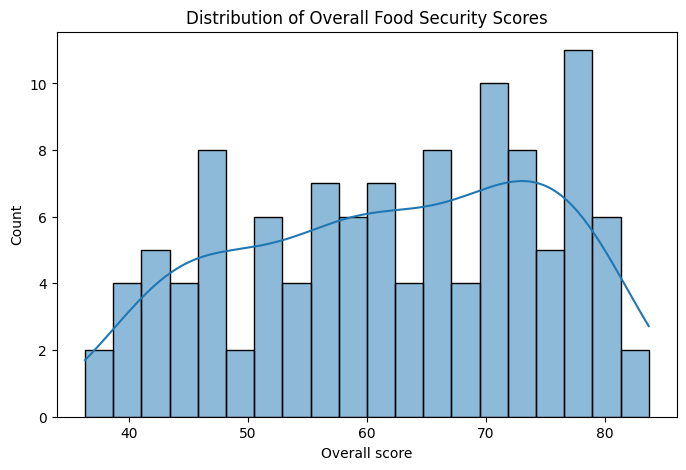

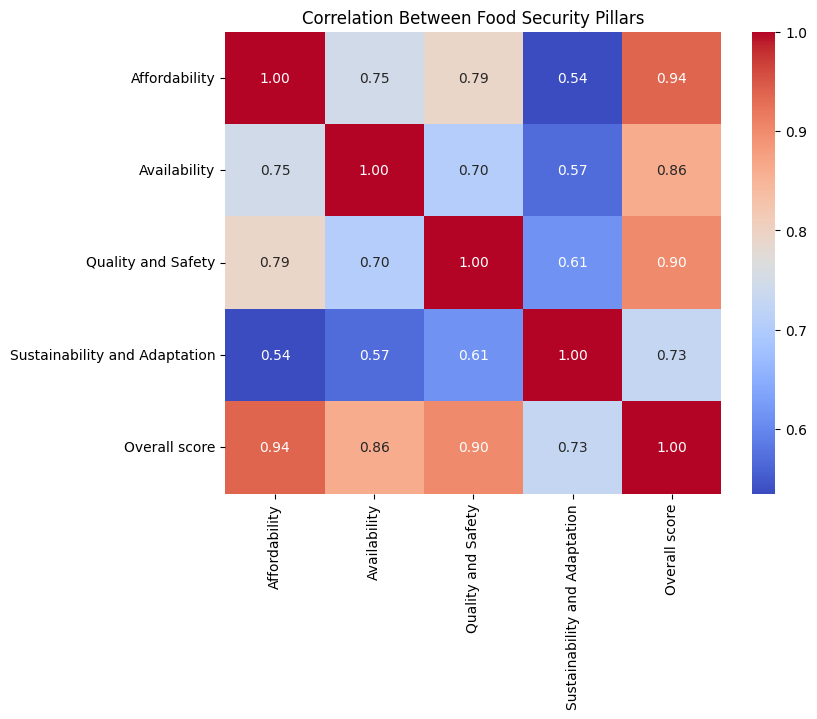

,Country,Overall score
112,Syria,36.3
111,Haiti,38.5
110,Yemen,40.1
109,Sierra Leone,40.5
108,Madagascar,40.6
107,Burundi,40.6
106,Nigeria,42.0
105,Venezuela,42.6
104,Sudan,42.8
103,Democratic Republic of Congo,43.0


In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['Overall score'], bins=20, kde=True)
plt.title('Distribution of Overall Food Security Scores')
plt.show()

pillars = ['Affordability', 'Availability', 'Quality and Safety', 'Sustainability and Adaptation']
plt.figure(figsize=(8,6))
sns.heatmap(df[pillars + ['Overall score']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Food Security Pillars')
plt.show()

df.sort_values('Overall score').head(10)[['Country', 'Overall score']]

## Step 4: Composite Risk Score

The GFSI `Overall score` is scaled 0–100, where a **higher score means better
food security**. We invert this to create a `risk_score` (higher = more risk),
then divide countries into three risk categories — **Low, Medium, High** —
using quantile-based bins so each group is roughly equal in size.

This risk score is the core analytical output of the system: it converts four
separate indicators into a single, decision-ready number.

In [5]:
df['risk_score'] = 100 - df['Overall score']
df['risk_category'] = pd.qcut(df['risk_score'], q=3, labels=['Low', 'Medium', 'High'])
df[['Country', 'risk_score', 'risk_category']].sort_values('risk_score', ascending=False).head(15)

,Country,risk_score,risk_category
112,Syria,63.7,High
111,Haiti,61.5,High
110,Yemen,59.9,High
109,Sierra Leone,59.5,High
108,Madagascar,59.4,High
107,Burundi,59.4,High
106,Nigeria,58.0,High
105,Venezuela,57.4,High
104,Sudan,57.2,High
103,Democratic Republic of Congo,57.0,High


### Result

The highest-risk countries — Syria, Haiti, Yemen, Sierra Leone, and Madagascar —
align with real-world food security concerns, confirming the risk score behaves
as expected. These countries fall into the **High** risk category, validating
that inverting the Overall score and using quantile-based bins produces a
sensible ranking.

## Step 5: Clustering with K-Means (Unsupervised ML)

While the risk score ranks countries individually, it doesn't show which
countries share a similar overall food security *profile*. We use **K-Means
clustering**, an unsupervised machine learning technique, on the four
standardized pillar scores to group countries with similar patterns —
even if their overall risk score differs.

This helps identify structurally similar groups of countries, which supports
more targeted policy recommendations than a single ranking alone.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pillars = ['Affordability', 'Availability', 'Quality and Safety', 'Sustainability and Adaptation']

X = df[pillars]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.groupby('cluster')[pillars + ['Overall score']].mean()

,Affordability,Availability,Quality and Safety,Sustainability and Adaptation,Overall score
cluster,,,,,
0,68.894737,57.371053,64.263158,50.118421,60.750000
1,86.781818,67.556818,79.293182,63.504545,75.056818
2,43.958065,44.419355,48.816129,45.751613,45.574194


### Cluster Interpretation

- **Cluster 1** (Overall ≈ 75.1): Strongest across all four pillars — likely
  wealthier, more food-secure nations.
- **Cluster 0** (Overall ≈ 60.75): Mid-range across all pillars, with
  Sustainability and Adaptation as the relative weak point.
- **Cluster 2** (Overall ≈ 45.6): Weakest across *every* pillar simultaneously —
  not a single point of failure but broad, compounding vulnerability. These
  countries likely require the most comprehensive intervention.

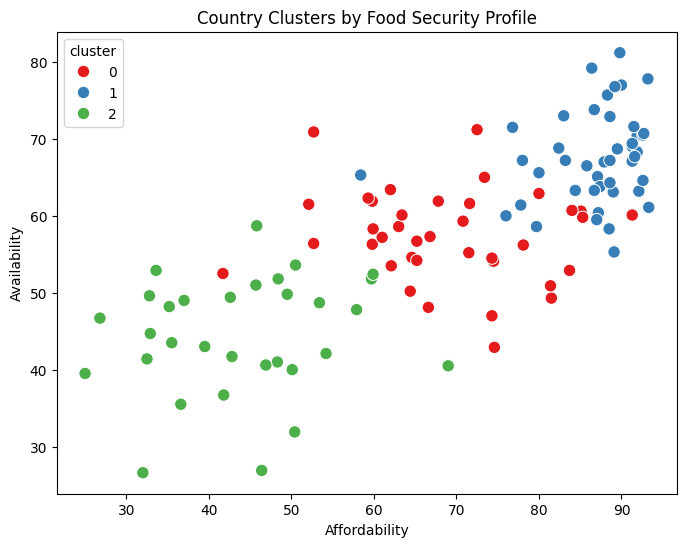

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Affordability', y='Availability', hue='cluster', palette='Set1', s=80)
plt.title('Country Clusters by Food Security Profile')
plt.show()

In [8]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score: {score:.3f}")

check = df[df['Country'].isin(['Syria', 'Yemen', 'Haiti', 'Sierra Leone'])]
print(check[['Country', 'risk_score', 'risk_category', 'cluster']])

Silhouette Score: 0.327
          Country  risk_score risk_category  cluster
109  Sierra Leone        59.5          High        2
110         Yemen        59.9          High        2
111         Haiti        61.5          High        2
112         Syria        63.7          High        2


### Validation

The silhouette score of **0.327** indicates moderate cluster separation —
reasonable given the real-world nature of country-level data, where boundaries
between food security profiles are naturally gradual rather than sharp.

As a sanity check, we confirmed that all four countries with the highest
`risk_score` (Syria, Haiti, Yemen, Sierra Leone) were also grouped into
**Cluster 2** — the cluster with the weakest average scores across all four
pillars. This agreement between the independently-computed risk score and the
unsupervised clustering result validates that both methods are capturing the
same real underlying pattern in the data.

## Step 6: Feature Importance with Random Forest (Supervised ML)

While K-Means clustering groups countries by overall profile, it doesn't tell us
*which* pillar matters most in driving risk. To answer this, we use a
**Random Forest Regressor** — a supervised machine learning technique — trained
to predict `risk_score` from the four pillar indicators.

We are not using this model to make future predictions (since the risk score is
derived directly from these same pillars). Instead, we use its **feature
importance output** as an interpretability tool: it ranks which pillar
(Affordability, Availability, Quality and Safety, or Sustainability and
Adaptation) has the strongest relationship with overall risk across the 113
countries.

This complements the clustering step — clustering shows *which countries* are
similar, while feature importance shows *what drives* risk in general. Together,
these two ML techniques (unsupervised clustering + supervised feature
importance) give a fuller picture: **who** is at risk, and **why**.

Quality and Safety               0.491027
Affordability                    0.374541
Availability                     0.097078
Sustainability and Adaptation    0.037355
dtype: float64


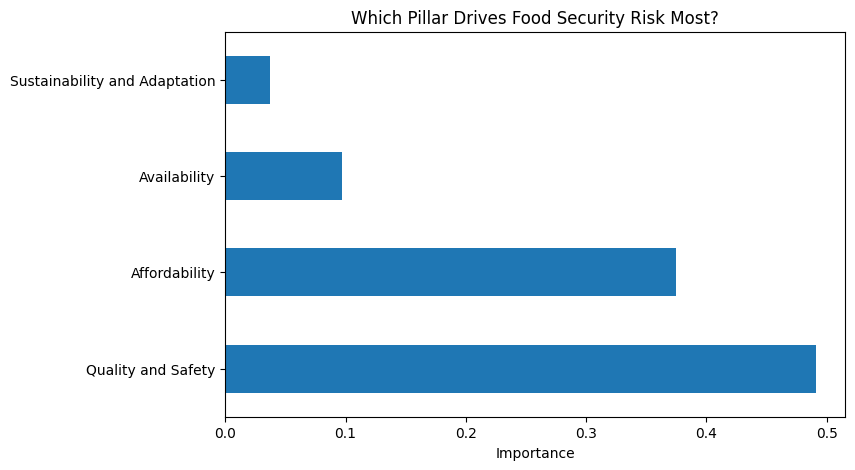

In [9]:
from sklearn.ensemble import RandomForestRegressor

X = df[pillars]
y = df['risk_score']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=pillars).sort_values(ascending=False)
print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind='barh')
plt.title('Which Pillar Drives Food Security Risk Most?')
plt.xlabel('Importance')
plt.show()

### Interpretation

The Random Forest analysis shows that *Quality and Safety* (importance:
0.491) is the strongest driver of overall food security risk, closely followed
by *Affordability* (importance: 0.375). Together, these two pillars account
for over 86% of the model's predictive weight, while *Availability* (0.097)
and *Sustainability and Adaptation* (0.037) play comparatively minor roles.

This suggests that interventions improving food quality/safety standards and
affordability are likely to have the greatest impact on a country's overall
food security standing — more so than improvements in raw availability or
long-term sustainability measures, at least based on this dataset's 2022
snapshot.

## Step 7: Save Processed Data

We save the cleaned dataset with all derived columns — risk score, risk
category, and cluster assignment — so it can be reused in the dashboard
without repeating the full pipeline.

In [10]:
df.to_csv('processed_food_security.csv', index=False)
print("Saved successfully")

Saved successfully


## Step 8: Machine Learning Prediction (Classification)

We will now train a model to predict the `risk_category` (Low, Medium, High) based on the four pillars. This demonstrates how the system could categorize new or hypothetical country data in the future.

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       1.00      1.00      1.00         8
      Medium       1.00      1.00      1.00         7

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



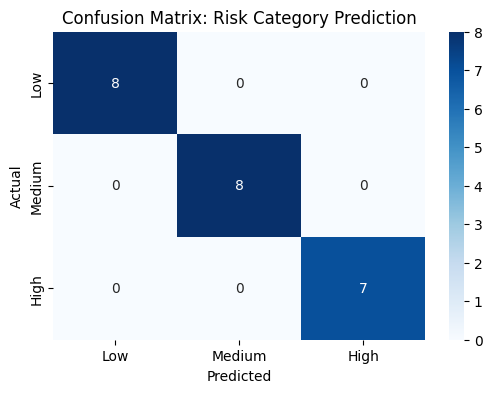

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Ensure data is loaded if not present
try:
    df = pd.read_csv('processed_food_security.csv')
except FileNotFoundError:
    # Fallback to creating it if the file was not saved
    df = pd.read_csv('Global Food Security Index 2022.csv')
    df['risk_score'] = 100 - df['Overall score']
    df['risk_category'] = pd.qcut(df['risk_score'], q=3, labels=['Low', 'Medium', 'High'])

pillars = ['Affordability', 'Availability', 'Quality and Safety', 'Sustainability and Adaptation']

# Prepare features and target
X = df[pillars]
y = df['risk_category']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix: Risk Category Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Step 9: Advanced ML Prediction - SVM and Cross-Validation

To ensure our predictions are robust and not just overfitting, we will use Support Vector Machines (SVM) for both classification and regression, and apply cross-validation to check consistency across different subsets of the data.

Regression R^2 Score (Cross-validated): 0.9990 (+/- 0.0015)
Classification Accuracy (Cross-validated): 0.7870 (+/- 0.3980)


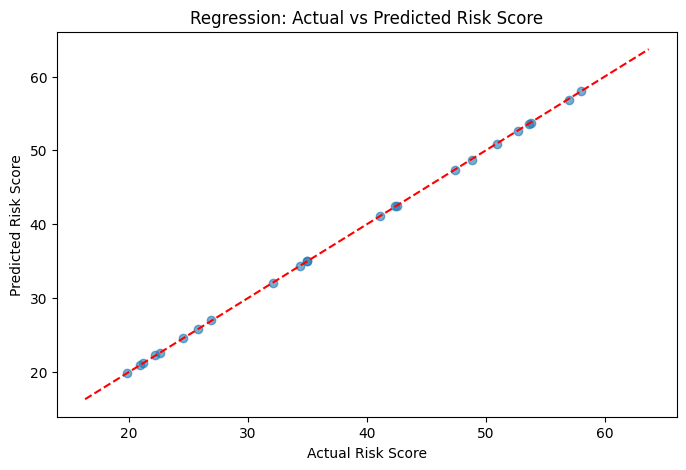

In [12]:
from sklearn.svm import SVR, SVC
from sklearn.model_selection import cross_val_score

# 1. Regression: Predicting the numerical risk_score
svr = SVR(kernel='linear')
scores_r2 = cross_val_score(svr, X_scaled, df['risk_score'], cv=5)

print(f"Regression R^2 Score (Cross-validated): {scores_r2.mean():.4f} (+/- {scores_r2.std() * 2:.4f})")

# 2. Classification: Predicting the risk_category
svc = SVC(kernel='linear', random_state=42)
scores_acc = cross_val_score(svc, X_scaled, df['risk_category'], cv=5)

print(f"Classification Accuracy (Cross-validated): {scores_acc.mean():.4f} (+/- {scores_acc.std() * 2:.4f})")

# Let's show a quick comparison of Actual vs Predicted Risk Scores
svr.fit(X_train, df.loc[X_train.index, 'risk_score'])
y_score_pred = svr.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(df.loc[X_test.index, 'risk_score'], y_score_pred, alpha=0.6)
plt.plot([df['risk_score'].min(), df['risk_score'].max()], [df['risk_score'].min(), df['risk_score'].max()], 'r--')
plt.title('Regression: Actual vs Predicted Risk Score')
plt.xlabel('Actual Risk Score')
plt.ylabel('Predicted Risk Score')
plt.show()

### Step 10: Anomaly Detection - Identifying Outlier Countries

Beyond just predicting risk, we want to find countries that are "statistical outliers." These are countries where the relationship between the four pillars is unusual, which might indicate a unique systemic issue or an exceptionally resilient food system.

Identified 6 outlier countries:
        Country  Overall score risk_category
0       Finland           83.7           Low
2        Norway           80.5           Low
108  Madagascar           40.6          High
110       Yemen           40.1          High
111       Haiti           38.5          High
112       Syria           36.3          High


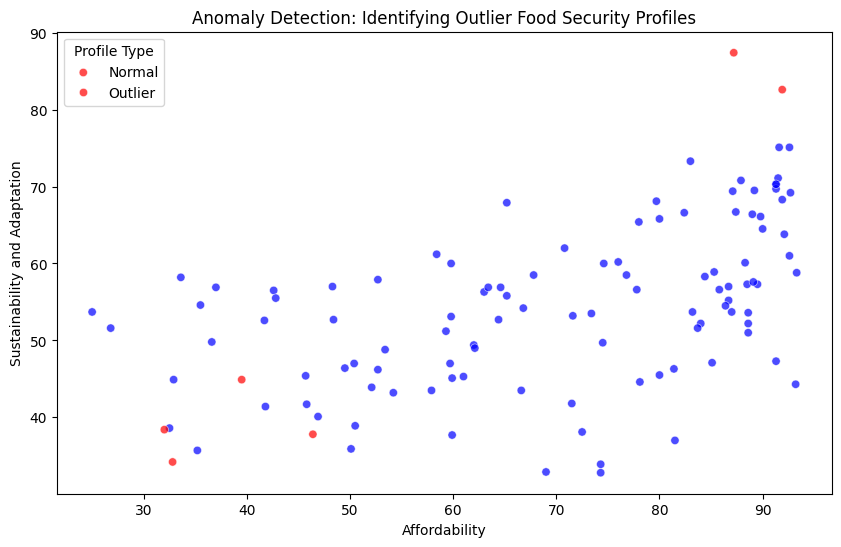

In [13]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the model on standardized pillar data
df['is_outlier'] = iso_forest.fit_predict(X_scaled)

# -1 indicates an outlier, 1 indicates a normal observation
outliers = df[df['is_outlier'] == -1]

print(f"Identified {len(outliers)} outlier countries:")
print(outliers[['Country', 'Overall score', 'risk_category']])

# Visualize outliers in a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Affordability', y='Sustainability and Adaptation',
                hue='is_outlier', palette={1: 'blue', -1: 'red'}, alpha=0.7)
plt.title('Anomaly Detection: Identifying Outlier Food Security Profiles')
plt.legend(title='Profile Type', labels=['Normal', 'Outlier'])
plt.show()

### Step 11: Interactive Risk Predictor

Use the sliders below to simulate a country's food security profile. The system will use the trained Random Forest and SVM models to predict the risk in real-time.

In [14]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Define sliders for each pillar
style = {'description_width': 'initial'}
aff_slider = widgets.FloatSlider(value=50, min=0, max=100, step=0.1, description='Affordability:', style=style)
avail_slider = widgets.FloatSlider(value=50, min=0, max=100, step=0.1, description='Availability:', style=style)
qual_slider = widgets.FloatSlider(value=50, min=0, max=100, step=0.1, description='Quality & Safety:', style=style)
sust_slider = widgets.FloatSlider(value=50, min=0, max=100, step=0.1, description='Sustainability:', style=style)

output = widgets.Output()

def predict_interactively(change):
    with output:
        clear_output(wait=True)

        # Prepare input data
        input_data = pd.DataFrame([[aff_slider.value, avail_slider.value, qual_slider.value, sust_slider.value]],
                                  columns=pillars)

        # 1. Predict Category (using Classifier)
        cat_pred = clf.predict(input_data)[0]

        # 2. Predict Exact Score (using Regressor)
        # Note: We use the SVR model fitted earlier
        score_pred = svr.predict(input_data)[0]

        print(f"--- Prediction Results ---")
        print(f"Predicted Risk Category: {cat_pred}")
        print(f"Predicted Risk Score:    {score_pred:.2f} / 100")

        # Visual indicator
        color = 'green' if cat_pred == 'Low' else 'orange' if cat_pred == 'Medium' else 'red'
        display(widgets.HTML(f"<div style='width: 100px; height: 20px; background-color: {color}; border: 1px solid black;'></div>"))

# Observe changes in any slider
for s in [aff_slider, avail_slider, qual_slider, sust_slider]:
    s.observe(predict_interactively, names='value')

# Layout
ui = widgets.VBox([aff_slider, avail_slider, qual_slider, sust_slider])
display(ui, output)

# Trigger initial prediction
predict_interactively(None)

Output()